# MVP v0.2.5.14: Fixed Guidance — Scaled-Up Positive-Only

**Date:** 2026-03-25  
**Builds on:** v0.2.5.13 (sigmoid reward), v0.2.5.6 (cross-policy guidance)  

## Changes from v0.2.5.13

1. **action_scale 0.001 → 0.01** (10x increase). Past sweeps show 0.001 is too weak  
   to differentiate policies (SR range 58-62% across 8-90% oracle SR).  
   v0.2.5.4 showed 0.01 is the upper bound of stable scales (43% MSE improvement).  
2. **Positive-only guidance** (no behavior subtraction).  
3. **BCGaussian behavior policy** trained on same 200 demos + 50 rollouts as the  
   chunk diffuser. Saved for future experiments (not used in positive-only mode).  
4. **Normalization stats saved** to checkpoint dir for reproducibility.  

## Setup

- **Chunk diffuser:** Pre-trained v0.2.5.2 EMA model (200 demos + 50 rollouts,  
  chunk_size=4, 256 diffusion steps, 50 epochs)  
- **Target policies:** 6 robomimic DiffusionPolicyUNet checkpoints (oracle SR 8-90%)  
- **Guidance:** `score_timestep=5`, `action_scale=0.01`, positive-only, `normalize_grad=True`  
- **Reward:** Both hard threshold and sigmoid (k=150), same as v0.2.5.13  

**Success criterion:** Spearman rho > 0.8 between guided OPE and oracle SR.

In [1]:
%matplotlib inline
import sys, os, importlib
import numpy as np
import torch
import torch.nn as nn
import h5py, json, math, time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_BASE = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models"
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
V0214_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0214_fixed_guidance"
ORACLE_JSON = PROJECT_ROOT / "results/2026-03-12/oracle_eval_all_checkpoints.json"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# Dims
STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = 26
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

# Diffuser config (must match v0.2.5.2 training)
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0

# Generation config
NUM_SYNTHETIC = 50
T_GEN = 60
GAMMA = 1.0

# Guidance config — 10x increase from v0.2.5.13
SCORE_TIMESTEP = 5
ACTION_SCALE = 0.01  # was 0.001 in v0.2.5.13
SIGMOID_SHARPNESS = 150.0

# BC Gaussian config
BC_HIDDEN = 256
BC_EPOCHS = 500
BC_BATCH = 256

# Target policies (same as v0.2.5.6/13)
TARGET_POLICIES = [
    {"name": "10demos_epoch10", "dir": "lift_diffusion_10demos/20260311115828", "ckpt": "models/model_epoch_10.pth"},
    {"name": "100demos_epoch20", "dir": "lift_diffusion_100demos/20260311135551", "ckpt": "models/model_epoch_20.pth"},
    {"name": "test_checkpoint", "dir": "test/20260309132349", "ckpt": "last.pth"},
    {"name": "10demos_epoch30", "dir": "lift_diffusion_10demos/20260311115828", "ckpt": "models/model_epoch_30.pth"},
    {"name": "50demos_epoch30", "dir": "lift_diffusion_50demos/20260311134204", "ckpt": "models/model_epoch_30.pth"},
    {"name": "200demos_epoch40", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_40.pth"},
]

print(f"score_timestep={SCORE_TIMESTEP}, action_scale={ACTION_SCALE}")
print(f"sigmoid_sharpness={SIGMOID_SHARPNESS}")
print(f"{NUM_SYNTHETIC} trajs, T_GEN={T_GEN}")
print(f"{len(TARGET_POLICIES)} target policies to evaluate")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
score_timestep=5, action_scale=0.01
sigmoid_sharpness=150.0
50 trajs, T_GEN=60
6 target policies to evaluate


In [2]:
# ── Reward functions ──

def hard_reward(cube_z):
    """Binary reward: 1 if cube_z > 0.84, else 0."""
    return (cube_z > LIFT_THRESHOLD).astype(np.float32)

def sigmoid_reward(cube_z, center=LIFT_THRESHOLD, sharpness=SIGMOID_SHARPNESS):
    """Smooth sigmoid reward centered at the lift threshold."""
    return (1.0 / (1.0 + np.exp(-sharpness * (cube_z - center)))).astype(np.float32)

def compute_ope_hard(states, gamma=1.0):
    B, T, _ = states.shape
    cube_z = states[:, :, CUBE_Z_INDEX]
    rewards = hard_reward(cube_z)
    gammas = gamma ** np.arange(T)
    return (rewards * gammas[None, :]).sum(axis=1)

def compute_ope_sigmoid(states, gamma=1.0):
    B, T, _ = states.shape
    cube_z = states[:, :, CUBE_Z_INDEX]
    rewards = sigmoid_reward(cube_z)
    gammas = gamma ** np.arange(T)
    return (rewards * gammas[None, :]).sum(axis=1)

def compute_sr_hard(states):
    B = states.shape[0]
    cube_z = states[:, :, CUBE_Z_INDEX]
    return np.mean([np.any(cube_z[j] > LIFT_THRESHOLD) for j in range(B)])

print("Reward/OPE functions defined.")

Reward/OPE functions defined.


In [3]:
# ── Load oracle results ──
with open(ORACLE_JSON, "r") as f:
    oracle_all = json.load(f)

oracle_sr_map = {}
for pol in TARGET_POLICIES:
    name = pol["name"]
    if name == "test_checkpoint":
        with open(CKPT_BASE / "test/20260309132349/oracle_50.json", "r") as f:
            test_oracle = json.load(f)
        oracle_sr_map[name] = float(test_oracle["mean_return"])
    else:
        oracle_sr_map[name] = float(oracle_all[name]["mean_return"])

print("Oracle SR values:")
for name, sr in oracle_sr_map.items():
    print(f"  {name:<22} {sr*100:.0f}%")

Oracle SR values:
  10demos_epoch10        8%
  100demos_epoch20       42%
  test_checkpoint        54%
  10demos_epoch30        62%
  50demos_epoch30        82%
  200demos_epoch40       90%


In [4]:
# ── Load data: 200 expert demos + 50 target rollouts ──
# This is the SAME data mix that the v0.2.5.2 diffuser was trained on.
# We need it to: (a) compute normalization, (b) train BC behavior policy,
# (c) extract initial states for generation.

all_states_list, all_actions_list = [], []
rollout_episodes = []  # for BC training

# 1. Load 50 target rollouts
target_data = []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    actions = actions.astype(np.float32)
    target_data.append({"states": states, "actions": actions})
    all_states_list.append(states)
    all_actions_list.append(actions)
    rollout_episodes.append({"states": states, "actions": actions})
print(f"Loaded {len(target_data)} target rollouts")

# 2. Load 200 expert demos
with h5py.File(DEMO_HDF5, "r") as f:
    for dk in sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1])):
        demo = f[f"data/{dk}"]
        states = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS], axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        all_states_list.append(states)
        all_actions_list.append(actions)
        rollout_episodes.append({"states": states, "actions": actions})
print(f"Loaded 200 expert demos")
print(f"Total episodes for BC training: {len(rollout_episodes)} (50 rollouts + 200 demos)")

# 3. Compute normalization (same as v0.2.5.2 training)
all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

# 4. Initial states for generation
initial_states_t = torch.tensor(
    np.array([ep["states"][0] for ep in target_data[:NUM_SYNTHETIC]]),
    dtype=torch.float32, device=device
)
print(f"Initial states: {initial_states_t.shape}")
print(f"Total (state, action) pairs for BC: {len(all_states)}")

Loaded 50 target rollouts


Loaded 200 expert demos
Total episodes for BC training: 250 (50 rollouts + 200 demos)
Initial states: torch.Size([50, 19])
Total (state, action) pairs for BC: 12341


In [5]:
# ── Load pre-trained diffuser (v0.2.5.2, trained on same 200 demos + 50 rollouts) ──
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)
ema = EMA(diffusion_model)
ema.ema_model.load_state_dict(
    torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
)
print(f"Loaded EMA diffuser from {DIFFUSION_SAVE_DIR}")

[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]


Loaded EMA diffuser from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


BC training data: 12341 (state, action) pairs from 250 episodes


BC trained: 500 epochs, final NLL=-7.2842, 4.3s
Saved BC behavior + norm stats to /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0214_fixed_guidance
Behavior grad norms: mean=32.62, std=12.34


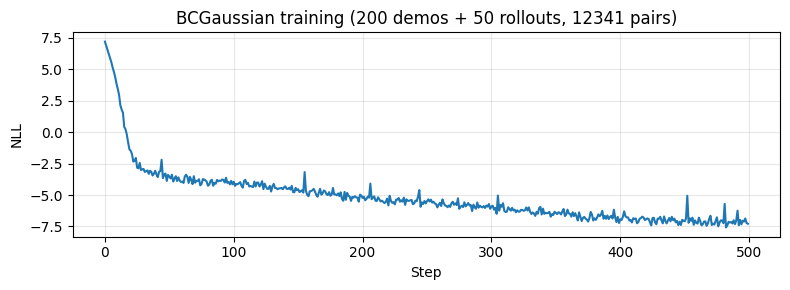

In [6]:
# ── Train BCGaussian behavior policy on 200 demos + 50 rollouts ──
# This matches the diffuser's training data. Saved for future experiments
# (not used in positive-only guidance mode).

class BCGaussian(nn.Module):
    """Simple BC policy with Gaussian output for SOPE-style guidance."""
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, action_dim)
        self.log_std_head = nn.Linear(hidden_dim, action_dim)

    def forward(self, state):
        h = self.net(state)
        return self.mean_head(h), self.log_std_head(h).clamp(-5, 2)

    def log_prob(self, state, action):
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        return -0.5 * (((action - mean) / std) ** 2 + 2 * log_std + math.log(2 * math.pi)).sum(dim=-1)

    def grad_log_prob(self, state, action):
        """Analytic gradient: -(a - mu) / sigma^2."""
        with torch.no_grad():
            mean, log_std = self.forward(state)
            std = torch.exp(log_std)
            return -(action - mean) / (std ** 2)

    def grad_log_prob_chunk(self, states, actions):
        B, T, _ = states.shape
        return self.grad_log_prob(
            states.reshape(B * T, -1), actions.reshape(B * T, -1)
        ).reshape(B, T, -1)


# Train on pooled data (200 demos + 50 rollouts)
bc_states = np.concatenate([ep["states"] for ep in rollout_episodes], axis=0)
bc_actions = np.concatenate([ep["actions"] for ep in rollout_episodes], axis=0)
print(f"BC training data: {len(bc_states)} (state, action) pairs from {len(rollout_episodes)} episodes")

bc_behavior = BCGaussian(STATE_DIM, ACTION_DIM, hidden_dim=BC_HIDDEN).to(device)
bc_optimizer = torch.optim.Adam(bc_behavior.parameters(), lr=1e-3)
bc_states_t = torch.tensor(bc_states, dtype=torch.float32, device=device)
bc_actions_t = torch.tensor(bc_actions, dtype=torch.float32, device=device)

bc_behavior.train()
bc_losses = []
t0 = time.time()
for bc_ep in range(BC_EPOCHS):
    idx = torch.randint(0, len(bc_states_t), (BC_BATCH,), device=device)
    nll = -bc_behavior.log_prob(bc_states_t[idx], bc_actions_t[idx]).mean()
    bc_optimizer.zero_grad()
    nll.backward()
    bc_optimizer.step()
    bc_losses.append(nll.item())
bc_time = time.time() - t0
bc_behavior.eval()
print(f"BC trained: {BC_EPOCHS} epochs, final NLL={bc_losses[-1]:.4f}, {bc_time:.1f}s")

# Save everything
V0214_SAVE_DIR.mkdir(parents=True, exist_ok=True)
torch.save(bc_behavior.state_dict(), V0214_SAVE_DIR / "bc_behavior.pt")
np.save(V0214_SAVE_DIR / "norm_mean.npy", norm_mean)
np.save(V0214_SAVE_DIR / "norm_std.npy", norm_std)
print(f"Saved BC behavior + norm stats to {V0214_SAVE_DIR}")

# Sanity check: gradient magnitudes
test_grad = bc_behavior.grad_log_prob(bc_states_t[:8], bc_actions_t[:8])
print(f"Behavior grad norms: mean={test_grad.norm(dim=-1).mean():.2f}, "
      f"std={test_grad.norm(dim=-1).std():.2f}")

# Plot training curve
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(bc_losses)
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title(f"BCGaussian training (200 demos + 50 rollouts, {len(bc_states)} pairs)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ── Trajectory generator (positive-only guidance) ──

def generate_trajectories(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen, device,
    target_scorer=None,
    action_scale=0.0, normalize_grad=True,
):
    guided = (target_scorer is not None and action_scale > 0)
    B = initial_states.shape[0]
    td = state_dim + action_dim
    n_ts = diffusion_model.n_timesteps

    pad = torch.cat([initial_states, torch.zeros(B, action_dim, device=device)], 1)
    cond_init = normalize_fn(pad)[:, :state_dim]
    all_traj = torch.zeros(B, t_gen, td, device=device)
    conditions = {0: cond_init}
    total = 0

    while total < t_gen:
        x = torch.randn(B, chunk_size, td, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_d in reversed(range(n_ts)):
            t_t = torch.full((B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = diffusion_model.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)

            if guided:
                # Unnormalize to get real-space values for scorer
                mm = unnormalize_fn(mm)
                sc = mm[:, :, :state_dim]
                ac = mm[:, :, state_dim:]

                # Positive-only guidance: grad_log_prob of target policy
                tg = target_scorer.grad_log_prob_chunk(sc, ac)
                if normalize_grad:
                    tg = tg / (tg.norm(dim=-1, keepdim=True) + 1e-6)

                # Apply guidance to actions only
                guide = torch.zeros_like(mm)
                guide[:, :, state_dim:] = tg
                mm = mm + action_scale * guide

                # Re-normalize, re-condition, then back to unnormalized
                # (matches SOPE's default_sample_fn flow: lines 182-244)
                mm = normalize_fn(mm)
                mm = apply_conditioning(mm, conditions, state_dim)
                mm = unnormalize_fn(mm)
                mm = normalize_fn(mm)

            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, conditions, state_dim)

        chunk_u = unnormalize_fn(x)
        n_store = min(chunk_size - 1, t_gen - total)
        all_traj[:, total:total+n_store] = chunk_u[:, 1:1+n_store]
        total += n_store

        if total < t_gen:
            last_state_norm = x[:, -1, :state_dim]
            conditions = {0: last_state_norm}

    return all_traj.cpu().numpy()

print("Generator ready.")

Generator ready.


In [8]:
# ── Generate unguided trajectories (once — same for all targets) ──
print("Generating unguided trajectories...")
np.random.seed(42)
torch.manual_seed(42)

t0 = time.time()
unguided_trajs = generate_trajectories(
    diffusion_model=ema.ema_model,
    initial_states=initial_states_t,
    normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
    state_dim=STATE_DIM, action_dim=ACTION_DIM,
    chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
)
unguided_time = time.time() - t0

unguided_states = unguided_trajs[:, :, :STATE_DIM]

# Score with both reward models
unguided_sr_hard = compute_sr_hard(unguided_states)
unguided_returns_hard = compute_ope_hard(unguided_states, GAMMA)
unguided_returns_sigmoid = compute_ope_sigmoid(unguided_states, GAMMA)

print(f"Unguided: hard SR={unguided_sr_hard*100:.0f}%, "
      f"hard OPE={unguided_returns_hard.mean():.3f}, "
      f"sigmoid OPE={unguided_returns_sigmoid.mean():.3f}, "
      f"{unguided_time:.0f}s")

# Cube z distribution
cube_z_max_per_traj = unguided_states[:, :, CUBE_Z_INDEX].max(axis=1)
print(f"Unguided cube_z max: mean={cube_z_max_per_traj.mean():.4f}, "
      f"std={cube_z_max_per_traj.std():.4f}, "
      f"range=[{cube_z_max_per_traj.min():.4f}, {cube_z_max_per_traj.max():.4f}]")

Generating unguided trajectories...


Unguided: hard SR=60%, hard OPE=5.020, sigmoid OPE=7.992, 30s
Unguided cube_z max: mean=0.8418, std=0.0101, range=[0.8225, 0.8551]


In [9]:
# ── Loop over target policies: generate guided trajectories ──
results = {}
t0_all = time.time()

for i, pol in enumerate(TARGET_POLICIES):
    name = pol["name"]
    oracle_sr = oracle_sr_map[name]
    run_dir = CKPT_BASE / pol["dir"]
    ckpt_file = pol["ckpt"]

    print(f"\n[{i+1}/{len(TARGET_POLICIES)}] {name} (oracle={oracle_sr*100:.0f}%)")

    # Load target policy
    print(f"  Loading checkpoint...", end=" ", flush=True)
    t0 = time.time()
    ckpt = load_checkpoint(run_dir, ckpt_path=Path(ckpt_file))
    target_algo = build_algo_from_checkpoint(ckpt, device=str(device))
    target_scorer = RobomimicDiffusionScorer(
        target_algo, device=str(device), score_timestep=SCORE_TIMESTEP, obs_keys=OBS_KEYS
    )
    load_time = time.time() - t0
    print(f"{load_time:.0f}s")

    # Generate guided trajectories
    print(f"  Generating guided trajectories (action_scale={ACTION_SCALE})...", end=" ", flush=True)
    np.random.seed(42)
    torch.manual_seed(42)
    t0 = time.time()
    guided_trajs = generate_trajectories(
        diffusion_model=ema.ema_model,
        initial_states=initial_states_t,
        normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM, action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
        target_scorer=target_scorer,
        action_scale=ACTION_SCALE, normalize_grad=True,
    )
    gen_time = time.time() - t0

    guided_states = guided_trajs[:, :, :STATE_DIM]

    # Score with both reward models
    guided_sr_hard = compute_sr_hard(guided_states)
    guided_returns_hard = compute_ope_hard(guided_states, GAMMA)
    guided_returns_sigmoid = compute_ope_sigmoid(guided_states, GAMMA)

    results[name] = {
        "oracle_sr": oracle_sr,
        "guided_sr_hard": guided_sr_hard,
        "guided_ope_hard": float(guided_returns_hard.mean()),
        "guided_ope_sigmoid": float(guided_returns_sigmoid.mean()),
        "guided_returns_hard": guided_returns_hard,
        "guided_returns_sigmoid": guided_returns_sigmoid,
        "guided_states": guided_states,
        "gen_time": gen_time,
    }

    print(f"{gen_time:.0f}s — hard SR={guided_sr_hard*100:.0f}%, "
          f"hard OPE={guided_returns_hard.mean():.3f}, "
          f"sigmoid OPE={guided_returns_sigmoid.mean():.3f} (oracle={oracle_sr*100:.0f}%)")

total_sweep_time = time.time() - t0_all
print(f"\nTotal sweep time: {total_sweep_time:.0f}s ({total_sweep_time/60:.1f} min)")


[1/6] 10demos_epoch10 (oracle=8%)
  Loading checkpoint... 


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos', 'object', 'robot0_eef_quat', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[14:26:49] INFO     build_algo_from_checkpoint took 0.39 seconds to execute                           ]8;id=855397;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=368051;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

1s
  Generating guided trajectories (action_scale=0.01)... 

...


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos', 'object', 'robot0_eef_quat', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[14:34:31] INFO     build_algo_from_checkpoint took 0.36 seconds to execute                           ]8;id=382144;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=764398;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

33s
  Generating guided trajectories (action_scale=0.01)... 

70s — hard SR=68%, hard OPE=4.400, sigmoid OPE=7.462 (oracle=90%)

Total sweep time: 533s (8.9 min)


In [10]:
# ── Summary table ──
print(f"{'='*110}")
print(f"v0.2.5.14 FIXED GUIDANCE — POSITIVE-ONLY, action_scale={ACTION_SCALE}")
print(f"Diffuser: v0.2.5.2 (200 demos + 50 rollouts, 54% SR behavior)")
print(f"Guidance: score_timestep={SCORE_TIMESTEP}, action_scale={ACTION_SCALE}, pos-only, normalize_grad=True")
print(f"{'='*110}")

unguided_ope_hard = float(unguided_returns_hard.mean())
unguided_ope_sigmoid = float(unguided_returns_sigmoid.mean())

header = (f"{'Policy':<22} {'Oracle':>7} {'U-Hard':>8} {'G-Hard':>8} "
          f"{'U-Sigm':>8} {'G-Sigm':>8} {'G-Sigm std':>10}")
print(f"\n{header}")
print("-" * 80)

oracle_srs = []
guided_opes_hard = []
guided_opes_sigmoid = []

for name in [p["name"] for p in TARGET_POLICIES]:
    r = results[name]
    osr = r["oracle_sr"]
    g_hard = r["guided_ope_hard"]
    g_sigm = r["guided_ope_sigmoid"]
    g_sigm_std = r["guided_returns_sigmoid"].std()

    oracle_srs.append(osr)
    guided_opes_hard.append(g_hard)
    guided_opes_sigmoid.append(g_sigm)

    print(f"{name:<22} {osr*100:>6.0f}% {unguided_ope_hard:>7.3f} {g_hard:>7.3f} "
          f"{unguided_ope_sigmoid:>7.3f} {g_sigm:>7.3f} {g_sigm_std:>9.3f}")

oracle_srs = np.array(oracle_srs)
guided_opes_hard = np.array(guided_opes_hard)
guided_opes_sigmoid = np.array(guided_opes_sigmoid)

# Rank correlations
rho_g_hard, p_g_hard = stats.spearmanr(oracle_srs, guided_opes_hard)
rho_g_sigm, p_g_sigm = stats.spearmanr(oracle_srs, guided_opes_sigmoid)

print(f"\n{'='*110}")
print(f"Spearman rho (guided,  hard    vs oracle): {rho_g_hard:+.4f}  (p={p_g_hard:.4f})")
print(f"Spearman rho (guided,  sigmoid vs oracle): {rho_g_sigm:+.4f}  (p={p_g_sigm:.4f})")
print(f"\nUnguided OPE: hard={unguided_ope_hard:.3f}, sigmoid={unguided_ope_sigmoid:.3f}")
print(f"Guided hard range:    [{guided_opes_hard.min():.3f}, {guided_opes_hard.max():.3f}]")
print(f"Guided sigmoid range: [{guided_opes_sigmoid.min():.3f}, {guided_opes_sigmoid.max():.3f}]")

if max(rho_g_hard, rho_g_sigm) > 0.8:
    print(f"\nSUCCESS: rho > 0.8 — guidance differentiates policies")
elif max(rho_g_hard, rho_g_sigm) > 0.5:
    print(f"\nPARTIAL: 0.5 < rho < 0.8 — some correlation")
else:
    print(f"\nFAIL: rho < 0.5 — guidance doesn't differentiate")

v0.2.5.14 FIXED GUIDANCE — POSITIVE-ONLY, action_scale=0.01
Diffuser: v0.2.5.2 (200 demos + 50 rollouts, 54% SR behavior)
Guidance: score_timestep=5, action_scale=0.01, pos-only, normalize_grad=True

Policy                  Oracle   U-Hard   G-Hard   U-Sigm   G-Sigm G-Sigm std
--------------------------------------------------------------------------------
10demos_epoch10             8%   5.020   2.960   7.992   6.238     2.917
100demos_epoch20           42%   5.020   4.220   7.992   7.276     3.716
test_checkpoint            54%   5.020   3.340   7.992   6.538     3.550
10demos_epoch30            62%   5.020   4.360   7.992   7.315     3.827
50demos_epoch30            82%   5.020   3.860   7.992   6.990     3.560
200demos_epoch40           90%   5.020   4.400   7.992   7.462     3.561

Spearman rho (guided,  hard    vs oracle): +0.7143  (p=0.1108)
Spearman rho (guided,  sigmoid vs oracle): +0.7143  (p=0.1108)

Unguided OPE: hard=5.020, sigmoid=7.992
Guided hard range:    [2.960, 4.400

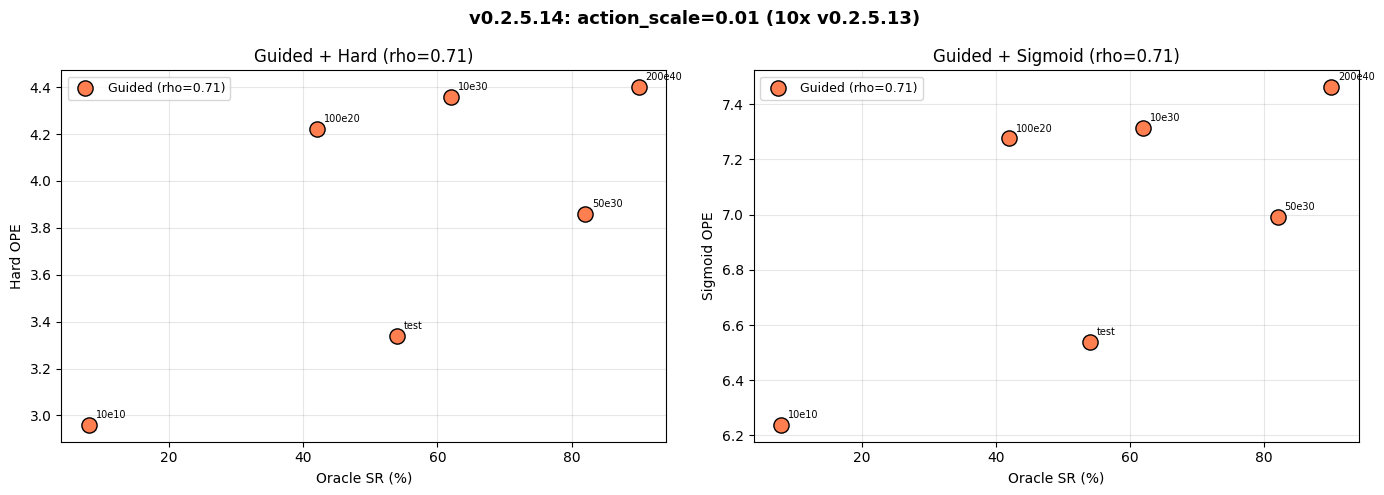

In [11]:
# ── Figure 1: Oracle vs OPE scatter (hard + sigmoid) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names_short = [p["name"].replace("demos_epoch", "e").replace("test_checkpoint", "test")
               for p in TARGET_POLICIES]

for ax, opes, reward_type, rho in [
    (axes[0], guided_opes_hard, "Hard", rho_g_hard),
    (axes[1], guided_opes_sigmoid, "Sigmoid", rho_g_sigm),
]:
    ax.scatter(oracle_srs * 100, opes, s=120, c="coral", edgecolor="black", zorder=5,
              label=f"Guided (rho={rho:.2f})")
    for j, n in enumerate(names_short):
        ax.annotate(n, (oracle_srs[j]*100, opes[j]),
                    textcoords="offset points", xytext=(5, 5), fontsize=7)
    ax.set_xlabel("Oracle SR (%)")
    ax.set_ylabel(f"{reward_type} OPE")
    ax.set_title(f"Guided + {reward_type} (rho={rho:.2f})")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"v0.2.5.14: action_scale={ACTION_SCALE} (10x v0.2.5.13)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

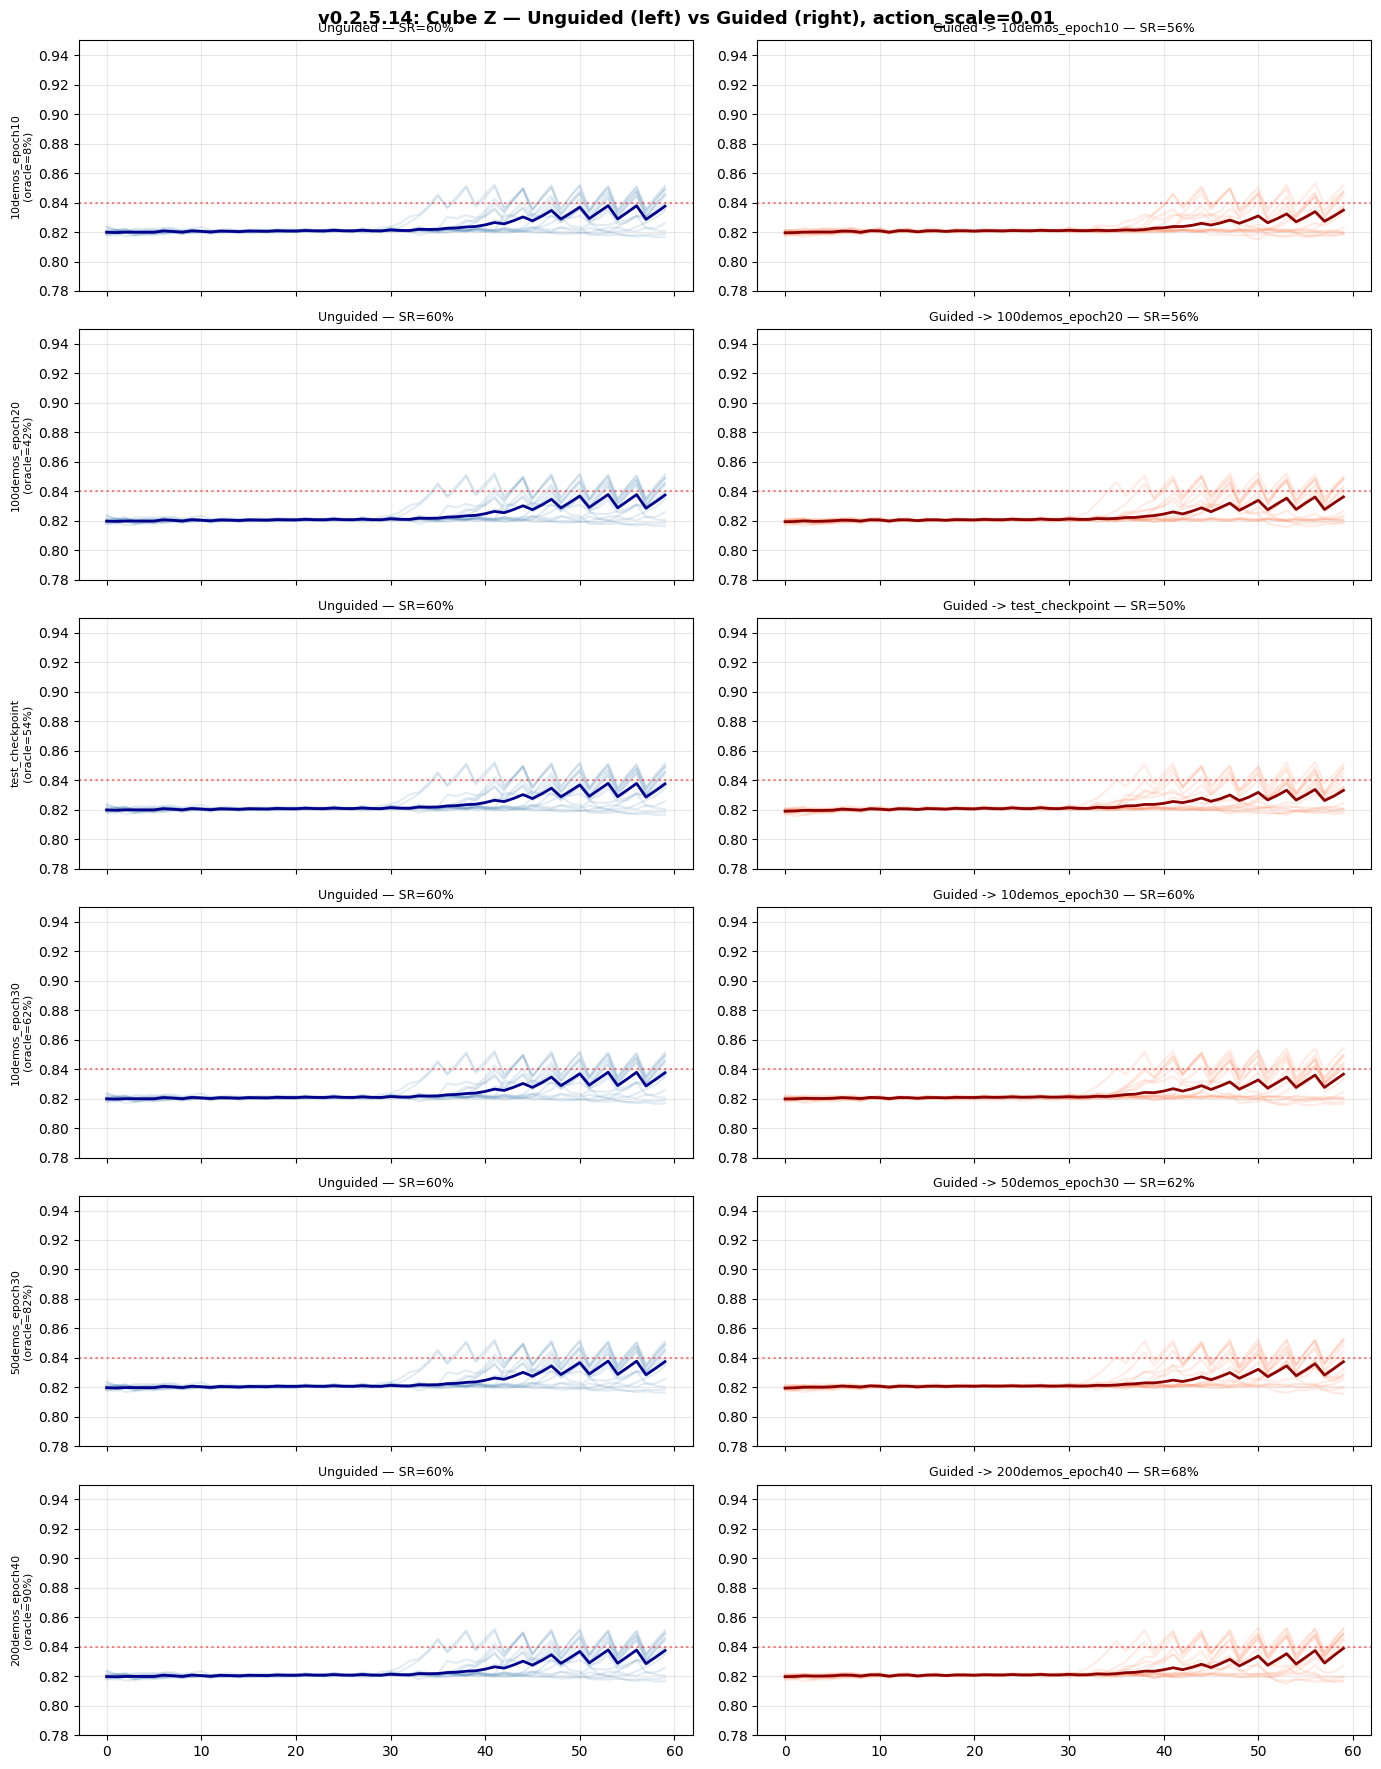

In [12]:
# ── Figure 2: Cube z trajectory grid (guided, per policy) ──
n_policies = len(TARGET_POLICIES)
fig, axes = plt.subplots(n_policies, 2, figsize=(14, 3 * n_policies), sharex=True)

for row, pol in enumerate(TARGET_POLICIES):
    name = pol["name"]
    r = results[name]
    osr = r["oracle_sr"]
    gs = r["guided_states"]

    # Left: unguided
    ax = axes[row, 0]
    for j in range(min(15, NUM_SYNTHETIC)):
        ax.plot(unguided_states[j, :, CUBE_Z_INDEX], color="steelblue", alpha=0.15)
    ax.plot(unguided_states[:, :, CUBE_Z_INDEX].mean(0), color="darkblue", lw=2)
    ax.axhline(y=LIFT_THRESHOLD, color="red", ls=":", alpha=0.5)
    ax.set_ylim([0.78, 0.95])
    ax.set_title(f"Unguided — SR={unguided_sr_hard*100:.0f}%", fontsize=9)
    ax.set_ylabel(f"{name}\n(oracle={osr*100:.0f}%)", fontsize=8)
    ax.grid(True, alpha=0.3)

    # Right: guided
    ax = axes[row, 1]
    for j in range(min(15, NUM_SYNTHETIC)):
        ax.plot(gs[j, :, CUBE_Z_INDEX], color="coral", alpha=0.15)
    ax.plot(gs[:, :, CUBE_Z_INDEX].mean(0), color="darkred", lw=2)
    ax.axhline(y=LIFT_THRESHOLD, color="red", ls=":", alpha=0.5)
    ax.set_ylim([0.78, 0.95])
    ax.set_title(f"Guided -> {name} — SR={r['guided_sr_hard']*100:.0f}%", fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"v0.2.5.14: Cube Z — Unguided (left) vs Guided (right), action_scale={ACTION_SCALE}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

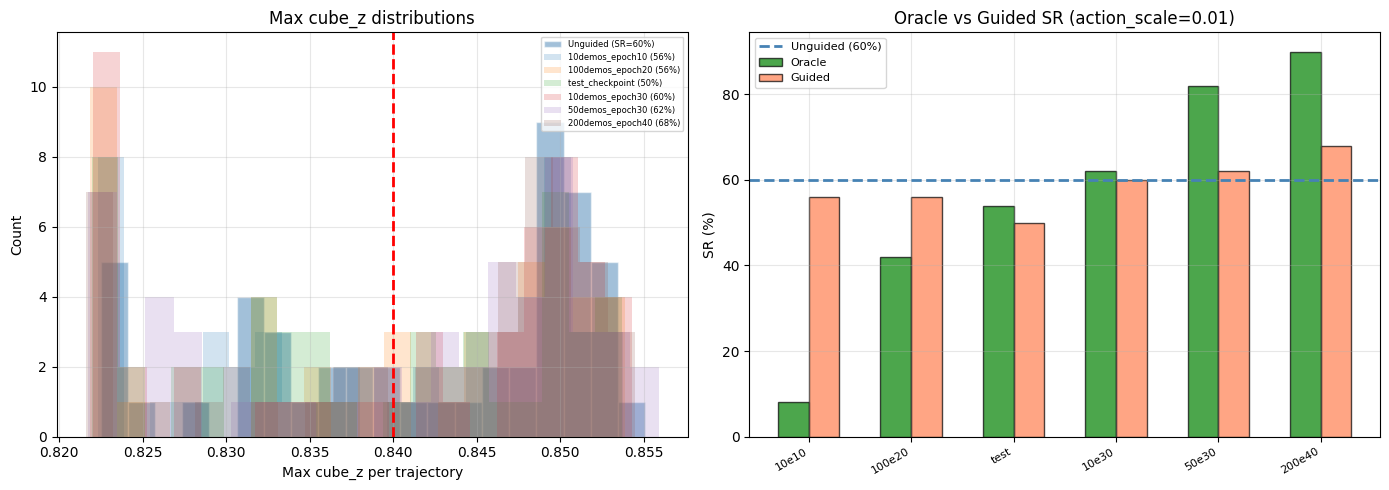

In [13]:
# ── Figure 3: Cube z max distribution comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Unguided vs all guided max cube_z histograms
ax = axes[0]
cube_z_max_u = unguided_states[:, :, CUBE_Z_INDEX].max(axis=1)
ax.hist(cube_z_max_u, bins=20, alpha=0.5, color="steelblue", edgecolor="white",
        label=f"Unguided (SR={unguided_sr_hard*100:.0f}%)")
for name in [p["name"] for p in TARGET_POLICIES]:
    r = results[name]
    czm = r["guided_states"][:, :, CUBE_Z_INDEX].max(axis=1)
    ax.hist(czm, bins=20, alpha=0.2, label=f"{name} ({r['guided_sr_hard']*100:.0f}%)")
ax.axvline(LIFT_THRESHOLD, color="red", ls="--", lw=2)
ax.set_xlabel("Max cube_z per trajectory")
ax.set_ylabel("Count")
ax.set_title("Max cube_z distributions")
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)

# Panel 2: Guided SR vs oracle SR bar chart
ax = axes[1]
x = np.arange(len(TARGET_POLICIES))
w = 0.3
ax.bar(x - w/2, oracle_srs * 100, w, color="green", edgecolor="black", alpha=0.7, label="Oracle")
guided_srs = [results[p["name"]]["guided_sr_hard"] * 100 for p in TARGET_POLICIES]
ax.bar(x + w/2, guided_srs, w, color="coral", edgecolor="black", alpha=0.7, label="Guided")
ax.axhline(unguided_sr_hard * 100, color="steelblue", ls="--", lw=2, label=f"Unguided ({unguided_sr_hard*100:.0f}%)")
ax.set_xticks(x)
ax.set_xticklabels([p["name"].replace("demos_epoch", "e").replace("test_checkpoint", "test")
                     for p in TARGET_POLICIES], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("SR (%)")
ax.set_title(f"Oracle vs Guided SR (action_scale={ACTION_SCALE})")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

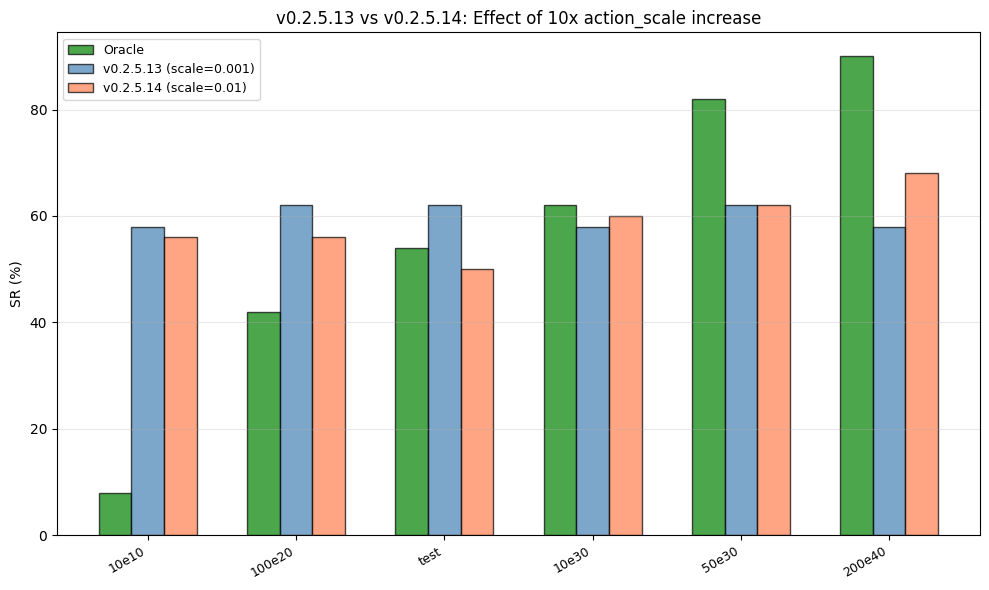


Guided SR range:
  v0.2.5.13 (scale=0.001): [58%, 62%]
  v0.2.5.14 (scale=0.01):  [50%, 68%]


In [14]:
# ── Figure 4: Comparison with v0.2.5.13 ──
# v0.2.5.13 results (action_scale=0.001) for reference
v13_guided_srs = {
    "10demos_epoch10": 0.58, "100demos_epoch20": 0.62, "test_checkpoint": 0.62,
    "10demos_epoch30": 0.58, "50demos_epoch30": 0.62, "200demos_epoch40": 0.58,
}

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
x = np.arange(len(TARGET_POLICIES))
w = 0.22
names_short = [p["name"].replace("demos_epoch", "e").replace("test_checkpoint", "test")
               for p in TARGET_POLICIES]

ax.bar(x - w, oracle_srs * 100, w, color="green", edgecolor="black", alpha=0.7, label="Oracle")
ax.bar(x, [v13_guided_srs[p["name"]] * 100 for p in TARGET_POLICIES], w,
       color="steelblue", edgecolor="black", alpha=0.7, label="v0.2.5.13 (scale=0.001)")
ax.bar(x + w, [results[p["name"]]["guided_sr_hard"] * 100 for p in TARGET_POLICIES], w,
       color="coral", edgecolor="black", alpha=0.7, label=f"v0.2.5.14 (scale={ACTION_SCALE})")

ax.set_xticks(x)
ax.set_xticklabels(names_short, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("SR (%)")
ax.set_title(f"v0.2.5.13 vs v0.2.5.14: Effect of 10x action_scale increase")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Print numeric comparison
print(f"\nGuided SR range:")
print(f"  v0.2.5.13 (scale=0.001): [{min(v13_guided_srs.values())*100:.0f}%, {max(v13_guided_srs.values())*100:.0f}%]")
guided_srs_v14 = [results[p["name"]]["guided_sr_hard"] for p in TARGET_POLICIES]
print(f"  v0.2.5.14 (scale={ACTION_SCALE}):  [{min(guided_srs_v14)*100:.0f}%, {max(guided_srs_v14)*100:.0f}%]")

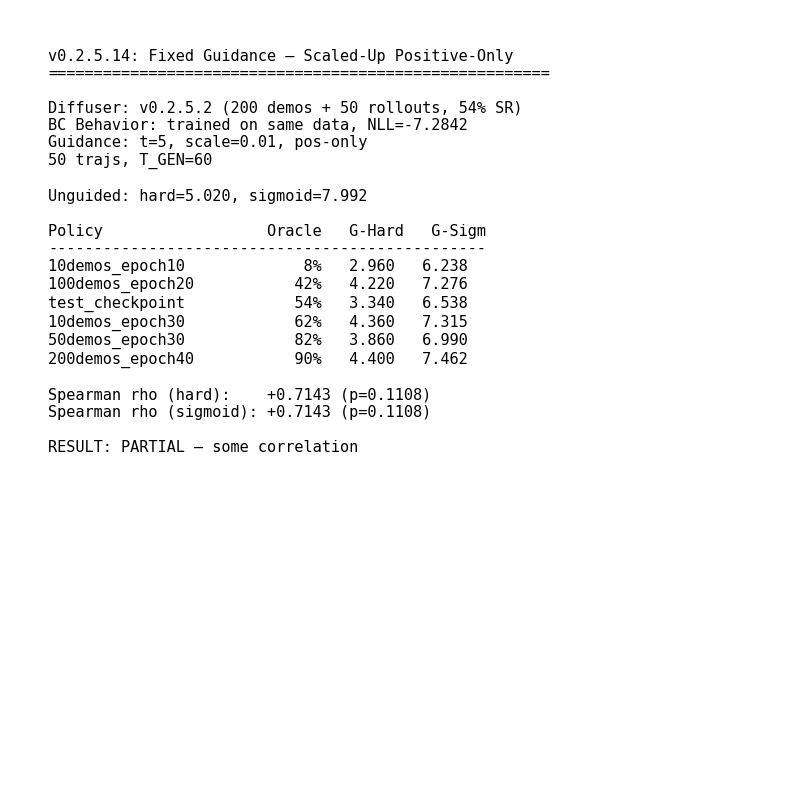

In [15]:
# ── Summary text ──
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.axis("off")

lines = [
    "v0.2.5.14: Fixed Guidance — Scaled-Up Positive-Only",
    "=" * 55,
    "",
    f"Diffuser: v0.2.5.2 (200 demos + 50 rollouts, 54% SR)",
    f"BC Behavior: trained on same data, NLL={bc_losses[-1]:.4f}",
    f"Guidance: t={SCORE_TIMESTEP}, scale={ACTION_SCALE}, pos-only",
    f"{NUM_SYNTHETIC} trajs, T_GEN={T_GEN}",
    "",
    f"Unguided: hard={unguided_ope_hard:.3f}, sigmoid={unguided_ope_sigmoid:.3f}",
    "",
]

lines.append(f"{'Policy':<22} {'Oracle':>7} {'G-Hard':>8} {'G-Sigm':>8}")
lines.append("-" * 48)
for name in [p["name"] for p in TARGET_POLICIES]:
    r = results[name]
    lines.append(f"{name:<22} {r['oracle_sr']*100:>6.0f}% {r['guided_ope_hard']:>7.3f} {r['guided_ope_sigmoid']:>7.3f}")

lines += [
    "",
    f"Spearman rho (hard):    {rho_g_hard:+.4f} (p={p_g_hard:.4f})",
    f"Spearman rho (sigmoid): {rho_g_sigm:+.4f} (p={p_g_sigm:.4f})",
    "",
]

best_rho = max(rho_g_hard, rho_g_sigm)
if best_rho > 0.8:
    lines.append("RESULT: SUCCESS")
elif best_rho > 0.5:
    lines.append("RESULT: PARTIAL — some correlation")
else:
    lines.append("RESULT: FAIL — guidance doesn't differentiate")

ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
        fontsize=11, verticalalignment="top", fontfamily="monospace")
plt.tight_layout()
plt.show()